In [163]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyecharts.charts as pyc
import pyecharts.options as opts
from statsmodels.tsa.stattools import adfuller, acf,pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error,mean_squared_error
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

## 一、数据获取

In [21]:
df_trade = pd.read_csv('tianchi_mum_baby_trade_history.csv')

df_baby = pd.read_csv('tianchi_mum_baby.csv')

In [22]:
df_baby.head()

,user_id,birthday,gender
0,2757,20130311,1
1,415971,20121111,0
2,1372572,20120130,1
3,10339332,20110910,0
4,10642245,20130213,0


In [23]:
df_trade.head()

,user_id,auction_id,cat_id,cat1,property,buy_mount,day
0,786295544,41098319944,50014866,50022520,21458:86755362;13023209:3593274;10984217:21985...,2,20140919
1,532110457,17916191097,50011993,28,21458:11399317;1628862:3251296;21475:137325;16...,1,20131011
2,249013725,21896936223,50012461,50014815,21458:30992;1628665:92012;1628665:3233938;1628...,1,20131011
3,917056007,12515996043,50018831,50014815,21458:15841995;21956:3494076;27000458:59723383...,2,20141023
4,444069173,20487688075,50013636,50008168,21458:30992;13658074:3323064;1628665:3233941;1...,1,20141103


## 二、数据预处理

In [24]:
df_trade.dtypes

user_id        int64
auction_id     int64
cat_id         int64
cat1           int64
property      object
buy_mount      int64
day            int64
dtype: object

In [25]:
df_trade['day'] = pd.to_datetime(df_trade.day.astype('str'))
df_trade.head()

,user_id,auction_id,cat_id,cat1,property,buy_mount,day
0,786295544,41098319944,50014866,50022520,21458:86755362;13023209:3593274;10984217:21985...,2,2014-09-19
1,532110457,17916191097,50011993,28,21458:11399317;1628862:3251296;21475:137325;16...,1,2013-10-11
2,249013725,21896936223,50012461,50014815,21458:30992;1628665:92012;1628665:3233938;1628...,1,2013-10-11
3,917056007,12515996043,50018831,50014815,21458:15841995;21956:3494076;27000458:59723383...,2,2014-10-23
4,444069173,20487688075,50013636,50008168,21458:30992;13658074:3323064;1628665:3233941;1...,1,2014-11-03


In [26]:
df_trade['year'] = df_trade.day.dt.year
df_trade['quarter'] = df_trade.day.dt.quarter
df_trade['month'] = df_trade.day.dt.month
df_trade.head()

,user_id,auction_id,cat_id,cat1,property,buy_mount,day,year,quarter,month
0,786295544,41098319944,50014866,50022520,21458:86755362;13023209:3593274;10984217:21985...,2,2014-09-19,2014,3,9
1,532110457,17916191097,50011993,28,21458:11399317;1628862:3251296;21475:137325;16...,1,2013-10-11,2013,4,10
2,249013725,21896936223,50012461,50014815,21458:30992;1628665:92012;1628665:3233938;1628...,1,2013-10-11,2013,4,10
3,917056007,12515996043,50018831,50014815,21458:15841995;21956:3494076;27000458:59723383...,2,2014-10-23,2014,4,10
4,444069173,20487688075,50013636,50008168,21458:30992;13658074:3323064;1628665:3233941;1...,1,2014-11-03,2014,4,11


上面完成了对df_trade时间列数据类型的修改和添加，接下来查看df_trade的时间跨度是否合理

In [27]:
df_trade.day.describe()

count                            29971
mean     2014-01-16 17:25:38.086817536
min                2012-07-02 00:00:00
25%                2013-06-20 00:00:00
50%                2014-03-06 00:00:00
75%                2014-09-09 00:00:00
max                2015-02-05 00:00:00
Name: day, dtype: object

从12年7月份到15年2月份，其中完整的年份是13、14年，合理。

接下来看宏观交易量数据

In [28]:
df_trade.buy_mount.describe()

count    29971.000000
mean         2.544126
std         63.986879
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max      10000.000000
Name: buy_mount, dtype: float64

可以看到，大部分的购买数量都是1（75%水位），但是最大值有10000次，考虑到母婴行业的特性，正常消费场景下，一般很少有一次性购买10000件的商品。一般我们取标准差(std)3倍以内的数据作为正常区间，63 * 3 = 189，我们保留buy_mount 189以内的数据：

In [29]:
df_trade = df_trade[(df_trade.buy_mount >= 1) & (df_trade.buy_mount <= 189)]
df_trade.buy_mount.describe()

count    29940.000000
mean         1.656179
std          5.026888
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        176.000000
Name: buy_mount, dtype: float64

可以看到，df_trade表原始数据有29971条，过滤后的数据有29940条。这样我们就完成了对df_trade的数据清洗。

In [31]:
count_user = df_trade.user_id.nunique()
count_auction = df_trade.auction_id.nunique()
count_category_1 = df_trade.cat1.nunique()
count_category_2 = df_trade.cat_id.nunique()
count_buy_mount = df_trade.buy_mount.sum()
print("用户数", count_user)
print("交易数", count_auction)
print("商品一级类目数：", count_category_1)
print("商品二级类目数：", count_category_2)
print("总销量：", count_buy_mount)

用户数 29913
交易数 28392
商品一级类目数： 6
商品二级类目数： 662
总销量： 49586


我们对df_baby表也做类似处理，为方便分析，过滤掉性别“未知”的数据条目，转换生日的数据类型，检查时间跨度是否合理：

In [33]:
df_baby.dtypes

user_id     int64
birthday    int64
gender      int64
dtype: object

In [34]:
df_baby.gender.describe()

count    953.000000
mean       0.514166
std        0.551981
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        2.000000
Name: gender, dtype: float64

In [35]:
df_baby = df_baby[df_baby.gender != 2]

In [36]:
df_baby['birthday'] = pd.to_datetime(df_baby.birthday.astype('str'))
df_baby.birthday.describe()

count                              927
mean     2012-03-04 16:37:16.893203712
min                1984-06-16 00:00:00
25%                2011-02-09 12:00:00
50%                2012-08-07 00:00:00
75%                2013-09-26 12:00:00
max                2015-08-15 00:00:00
Name: birthday, dtype: object

我们发现居然有1984年出生的婴儿数据，因为淘宝网是2003年才诞生的，网购的消费习惯多形成在2010年前后，因此我们剔除掉异常的生日数据：

In [37]:
df_baby = df_baby[df_baby.birthday > '2010-01-01']
df_baby.birthday.describe()

count                              798
mean     2012-11-01 04:10:49.624060160
min                2010-01-05 00:00:00
25%                2011-10-17 18:00:00
50%                2012-11-25 00:00:00
75%                2013-11-23 06:00:00
max                2015-08-15 00:00:00
Name: birthday, dtype: object

可以看到，经过数据过滤后，df_baby表的数据从原始的953条缩小到798条。这样，我们就完成了对df_baby的数据清洗。

## 三、数据分析

我们从时间、商品类目、用户性别这3个维度对df_trade表和df_baby表进行数据分析和可视化：

### 3.1 流量分析
我们从年、季度、月、天的角度来对购买量进行分析：

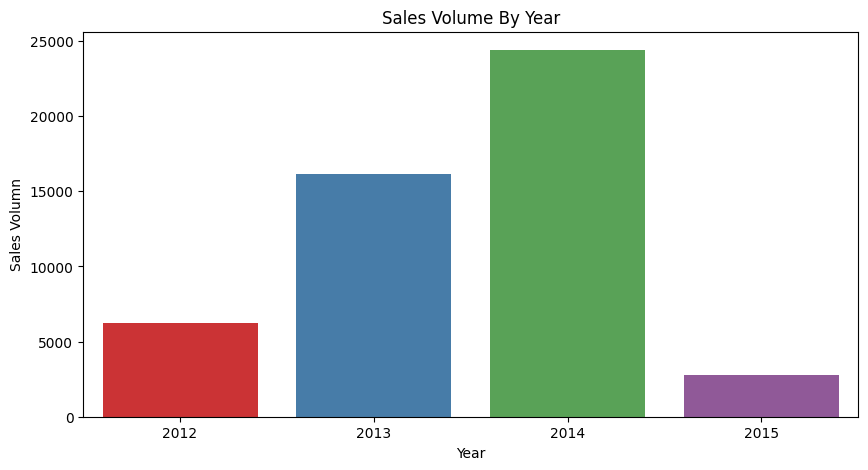

In [45]:
# 根据年月查看销量趋势
year_stats = df_trade.groupby(by='year')['buy_mount'].sum()

plt.figure(figsize=(10, 5))
sns.barplot(x=year_stats.index, y=year_stats.values, palette='Set1')

plt.title("Sales Volume By Year")
plt.xlabel("Year")
plt.ylabel("Sales Volumn")
plt.show()

在数据预处理章节我们得知，本次抽样数据跨度为2012/07到2015/02，2013、2014为两个完整的年份，趋势应该是逐年递增的，符合常识。

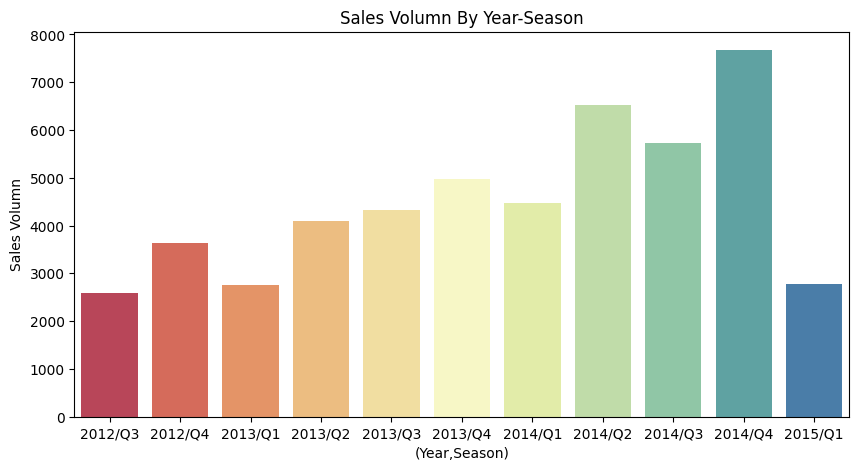

In [68]:
# 各年季度销量情况
year_quarter_stats = df_trade.groupby(by=['year', 'quarter'])['buy_mount'].sum()

plt.figure(figsize=(10, 5))
# year_quarter_stats.index：
# MultiIndex([(2012,  7),
#             (2012,  8),
#             ...
#            (2015,  1),
#            (2015,  2)])
x_list = [str(idx[0]) + "/Q" + str(idx[1]) for idx in year_quarter_stats.index]
y_list = [int(value) for value in year_quarter_stats.values]
sns.barplot(x=x_list, y=y_list,palette='Spectral')
plt.title("Sales Volume By Year")
plt.xlabel("Year")
plt.title("Sales Volumn By Year-Season")
plt.xlabel("(Year,Season)")
plt.ylabel("Sales Volumn")
plt.show()

以2013、2014两个完整年为例，一般规律是Q1为全年销量最低的年份、Q4是全年销量最高的年份，猜想一个可能的原因是Q1因为春节假期导致的销量下滑，Q4是因为有双十一、双十二营销活动带来的增长。我们可以再按月分析来验证我们的结论：

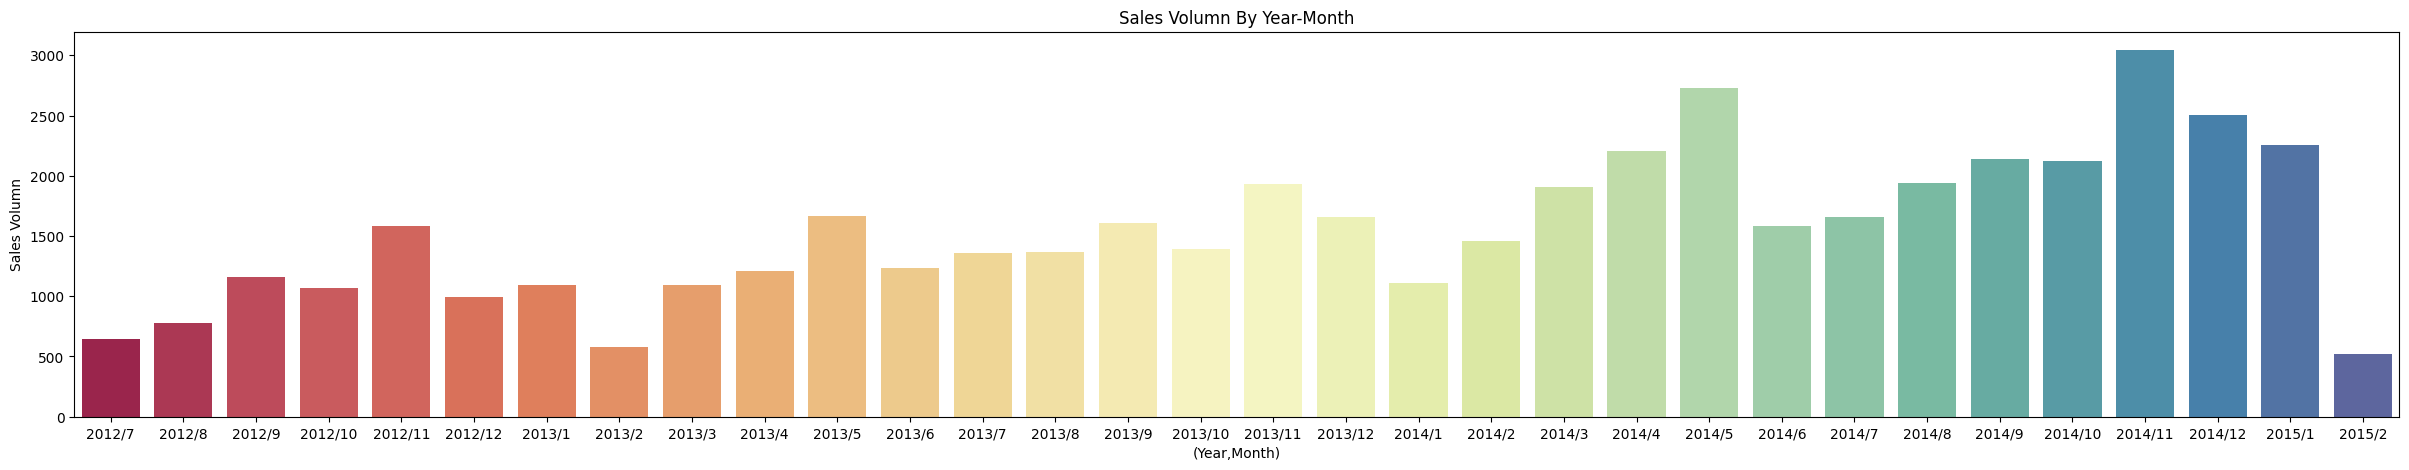

In [70]:
# 根据年月分组
year_month_stats = df_trade.groupby(by=['year', 'month'])['buy_mount'].sum()

plt.figure(figsize=(30, 5))
x_list = [str(idx[0]) + "/" + str(idx[1]) for idx in year_month_stats.index]
y_list = [int(value) for value in year_month_stats.values]
sns.barplot(x=x_list, y=y_list,palette='Spectral')

plt.title("Sales Volumn By Year-Month")
plt.xlabel("(Year,Month)")
plt.ylabel("Sales Volumn")
plt.show()

还是以2013、2014年为例，2013年2月份、2014年1月份为全年销量最低，通过万年历查询我们知道这两个月份刚好位当年的春节所在的月份，11月份分别为两年的销售高峰。初步印证了我们关于春节和双十一营销活动对销量带来影响的猜想。 我们可以更进一步，以天为单位来观察销量数据，我们仅以2014年11月的数据为例，2014年1月份的数据趋势，以及2013年2月份、2013年11月的数据趋势：

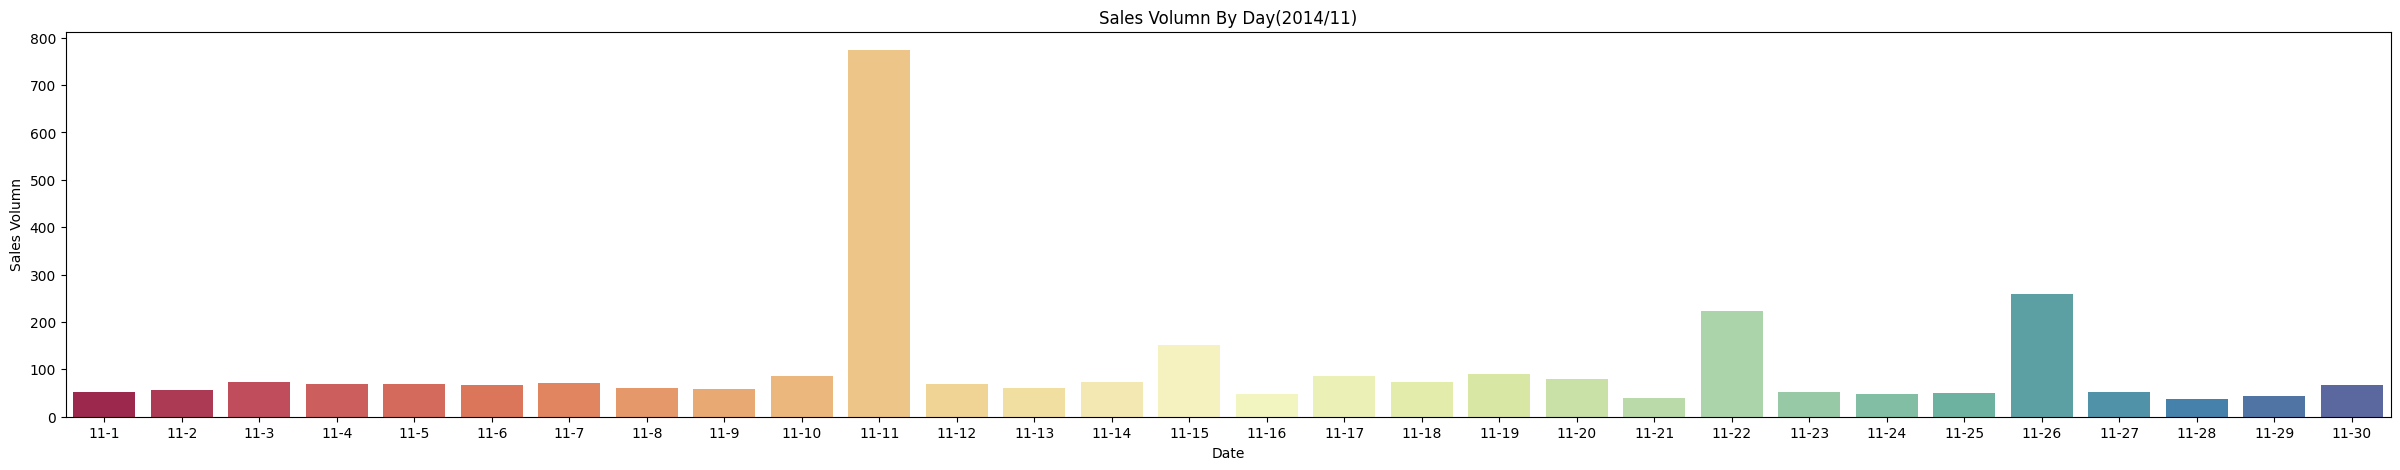

In [73]:
df_trade_201411 = df_trade[(df_trade.day >= '2014-11-01') & (df_trade.day <= '2014-11-30')]
day_stats = df_trade_201411.groupby(by='day')['buy_mount'].sum()

plt.figure(figsize=(30, 5))
x_list = [str(idx.month) + '-' + str(idx.day) for idx in day_stats.index]
y_list = [int(value) for value in day_stats.values]
sns.barplot(x=x_list, y=y_list,palette='Spectral')

plt.title("Sales Volumn By Day(2014/11)")
plt.xlabel("Date")
plt.ylabel("Sales Volumn")
plt.show()

可以看到，相比其他日期，双11购物节当天的销量出现了顶峰。 完成年/季度/月/日的销量分析后，我们再来看看商品类目的销售情况。

### 3.2类目分析

在数据预处理中，我们知道本次抽样数据共包含6个商品大类（一级类目），662个商品二级类目。因本次抽样数据样本量较小，因此我们主要分析商品一级类目。 我们先来看看商品一级类目的销量情况：

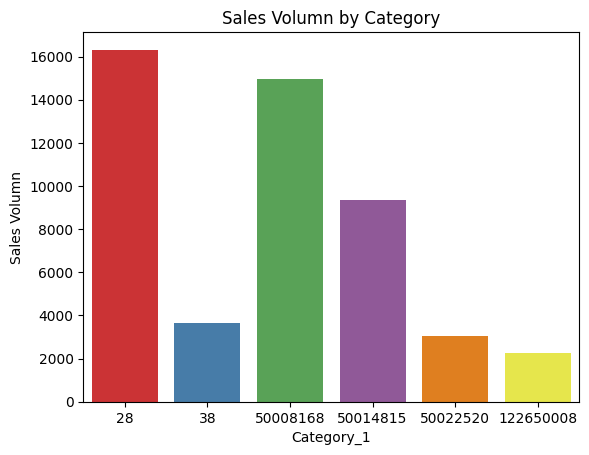

In [75]:
# 商品大类销售情况
category_1_stats = df_trade.groupby(by="cat1")['buy_mount'].sum()
sns.barplot(x=category_1_stats.index, y=category_1_stats.values,palette='Set1')
plt.title("Sales Volumn by Category")
plt.xlabel("Category_1")
plt.ylabel('Sales Volumn')
plt.show()

我们再来分析下每个大类下子类的数量：

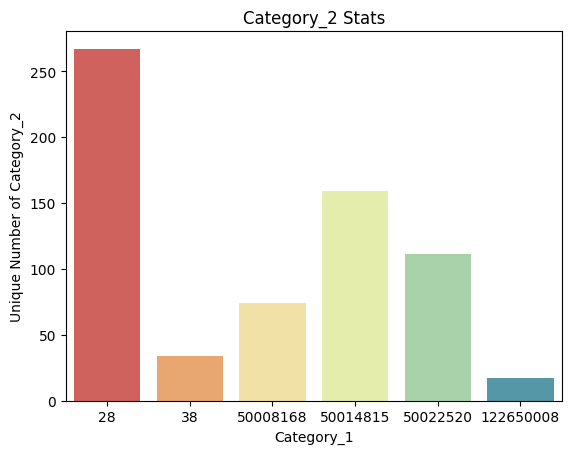

In [79]:
# 一级类目下二级类别数量
category_2_stats = df_trade.groupby('cat1')['cat_id'].nunique()
sns.barplot(x=category_2_stats.index, y=category_2_stats.values,palette='Spectral')
plt.title("Category_2 Stats")
plt.xlabel("Category_1")
plt.ylabel("Unique Number of Category_2")
plt.show()

我们再来看看大类下每个子类的平均销售贡献：

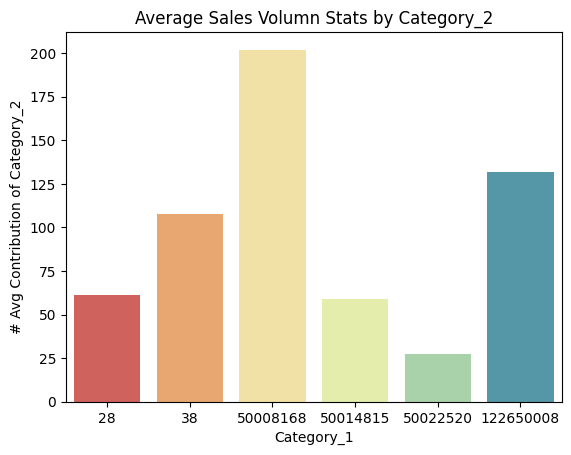

In [84]:
# 人均大类购买情况
ave_category_stats = (df_trade.groupby("cat1")['buy_mount'].sum() / df_trade.groupby("cat1")['cat_id'].nunique())

sns.barplot(x=ave_category_stats.index, y=ave_category_stats.values,palette='Spectral')
plt.title("Average Sales Volumn Stats by Category_2")
plt.xlabel("Category_1")
plt.ylabel("# Avg Contribution of Category_2")
plt.show()

可以看出，淡黄色（50008168）类目虽然子类数量少，但是子类的平均销量贡献度大。猜测可能是婴幼儿奶粉、尿不湿等刚需大的类目。 对类目做完分析后，我们再来看看性别维度和商品销量结合起来，我们能洞察到什么有趣的结论：

### 3.2性别分析

In [85]:
df_merge = pd.merge(df_trade, df_baby)
df_merge

,user_id,auction_id,cat_id,cat1,property,buy_mount,day,year,quarter,month,birthday,gender
0,513441334,19909384116,50010557,50008168,25935:21991;1628665:29784;22019:34731;22019:20...,1,2012-12-12,2012,4,12,2011-01-05,1
1,377550424,15771663914,50015841,28,1628665:3233941;1628665:3233942;3914866:11580;...,1,2012-11-23,2012,4,11,2011-06-20,1
2,47342027,14066344263,50013636,50008168,21458:21599;13585028:3416646;1628665:3233942;1...,1,2012-09-11,2012,3,9,2010-10-08,1
3,119784861,20796936076,50140021,50008168,21458:120325094;22019:2026;22019:34731;22019:3...,1,2012-11-29,2012,4,11,2012-03-27,0
4,159129426,15198386301,50013711,50008168,21458:11580;1628665:29778;22019:3340598;22019:...,2,2012-08-08,2012,3,8,2010-08-25,0
...,...,...,...,...,...,...,...,...,...,...,...,...
796,379910739,12881672070,50012451,50008168,1628665:3233941;22019:3228688;22019:3265977;22...,2,2012-09-04,2012,3,9,2011-02-26,0
797,685332320,12781785338,50018831,50014815,21458:4348502;1629846:4344686;1828368:39447633...,2,2013-06-01,2013,2,6,2012-02-23,0
798,389326420,17164967407,50006820,28,21458:125625318;50167493:3366864;21475:2757081...,1,2014-09-16,2014,3,9,2013-07-17,0
799,1372572,16915013171,50008845,28,21458:30992;1628665:3233941;1628665:3233942;16...,1,2013-03-27,2013,1,3,2012-01-30,1


我们可以根据交易时间和孩子出生日期来判断孩子的年龄：

In [86]:
df_merge['age'] = round(( df_merge['day'] - df_merge['birthday'] ) / pd.Timedelta(days = 365) , 2)
df_merge

,user_id,auction_id,cat_id,cat1,property,buy_mount,day,year,quarter,month,birthday,gender,age
0,513441334,19909384116,50010557,50008168,25935:21991;1628665:29784;22019:34731;22019:20...,1,2012-12-12,2012,4,12,2011-01-05,1,1.94
1,377550424,15771663914,50015841,28,1628665:3233941;1628665:3233942;3914866:11580;...,1,2012-11-23,2012,4,11,2011-06-20,1,1.43
2,47342027,14066344263,50013636,50008168,21458:21599;13585028:3416646;1628665:3233942;1...,1,2012-09-11,2012,3,9,2010-10-08,1,1.93
3,119784861,20796936076,50140021,50008168,21458:120325094;22019:2026;22019:34731;22019:3...,1,2012-11-29,2012,4,11,2012-03-27,0,0.68
4,159129426,15198386301,50013711,50008168,21458:11580;1628665:29778;22019:3340598;22019:...,2,2012-08-08,2012,3,8,2010-08-25,0,1.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,379910739,12881672070,50012451,50008168,1628665:3233941;22019:3228688;22019:3265977;22...,2,2012-09-04,2012,3,9,2011-02-26,0,1.52
797,685332320,12781785338,50018831,50014815,21458:4348502;1629846:4344686;1828368:39447633...,2,2013-06-01,2013,2,6,2012-02-23,0,1.27
798,389326420,17164967407,50006820,28,21458:125625318;50167493:3366864;21475:2757081...,1,2014-09-16,2014,3,9,2013-07-17,0,1.17
799,1372572,16915013171,50008845,28,21458:30992;1628665:3233941;1628665:3233942;16...,1,2013-03-27,2013,1,3,2012-01-30,1,1.16


In [87]:
df_merge.age.describe()

count    801.000000
mean       1.205106
std        1.267036
min       -2.090000
25%        0.250000
50%        0.980000
75%        2.080000
max        4.840000
Name: age, dtype: float64

我们发现年龄的最小值有负数，因此我们过滤掉年龄小于0的数据, 最终得到663条数据, 最大年龄4岁，最小年龄为刚出生的婴儿，平均年龄为1.5岁。

In [88]:
df_merge = df_merge[df_merge.age > 0]
df_merge.age.describe()

count    663.000000
mean       1.537979
std        1.122517
min        0.020000
25%        0.590000
50%        1.250000
75%        2.300000
max        4.840000
Name: age, dtype: float64

我们先来统计下性别比例：

In [89]:
# 计算比例函数
def compute_fraction(pct, allvals):
    absolute = int(pct/100 * np.sum(allvals))
    return '{:.2f}%\n{:d}'.format(pct, absolute)

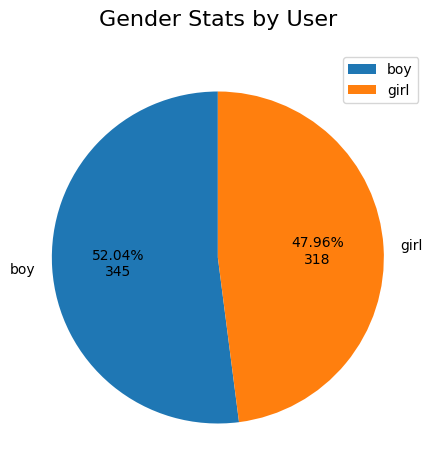

In [90]:
gender_stats_by_user = df_merge.groupby(by = "gender")["user_id"].count()
#gender_stats_by_auction = df_merge.groupby(by = "gender")["auction_id"].count()

labels=['boy','girl']
values=np.array([gender_stats_by_user[0], gender_stats_by_user[1]])

fig=plt.figure()
sub=fig.add_subplot(111)
sub.pie(values, labels=labels, startangle=90, autopct=lambda x: compute_fraction(x,values))
sub.legend()
fig.suptitle('Gender Stats by User',fontsize=16)
fig.tight_layout()
plt.show()

我们再来统计性别在商品大类销售中的体现，看看能看到什么规律：

In [91]:
gender_stats_by_buy_mount = df_merge.groupby(by = ['gender','cat1'])['buy_mount'].sum()

gender_stats_by_buy_mount

gender  cat1     
0       28           112
        38            94
        50008168     154
        50014815     303
        50022520      14
        122650008     23
1       28            81
        38            37
        50008168     158
        50014815      87
        50022520      14
        122650008     19
Name: buy_mount, dtype: int64

In [92]:
category_1_list = [28, 38, 50008168, 50014815, 50022520, 122650008]

Text(0.5, 0.98, 'Sales Volumn by Boy')

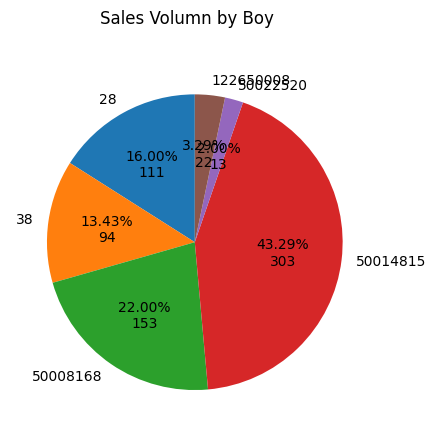

In [93]:
# 男孩的类别销量统计：
values = np.array([gender_stats_by_buy_mount.loc[0, category] for category in category_1_list])

fig=plt.figure()
sub=fig.add_subplot(111)
sub.pie(values, labels=category_1_list, startangle=90, autopct=lambda x: compute_fraction(x,values))
fig.suptitle('Sales Volumn by Boy')

Text(0.5, 0.98, 'Sales Volumn by Girl')

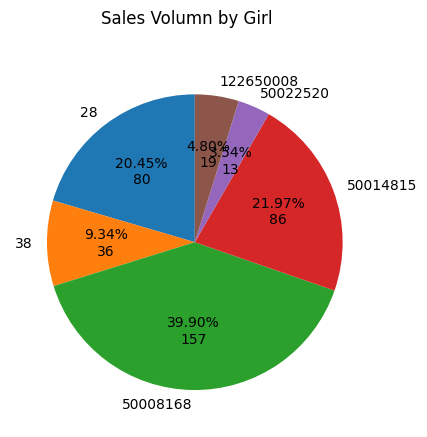

In [94]:
# 女孩的类别销量统计：
values = np.array([gender_stats_by_buy_mount.loc[1, category] for category in category_1_list])

fig=plt.figure()
sub=fig.add_subplot(111)
sub.pie(values, labels=category_1_list, startangle=90, autopct=lambda x: compute_fraction(x,values))
fig.suptitle('Sales Volumn by Girl')

可以看出，男、女两类婴幼儿用户的购买类别比例还是有较为明显的区别，和我们的常识有所出入。

## 四、时间序列分析

In [99]:
# 1. 提取时间序列：day + buy_amount
ts = df_trade[['day', 'buy_mount']].copy()
ts = ts.groupby('day')['buy_mount'].sum().reset_index()  # 按天聚合销量
ts.set_index('day', inplace=True)
ts = ts.asfreq('D')  # 按天频率
ts = ts.fillna(0)    # 空天填0
y = ts['buy_mount']

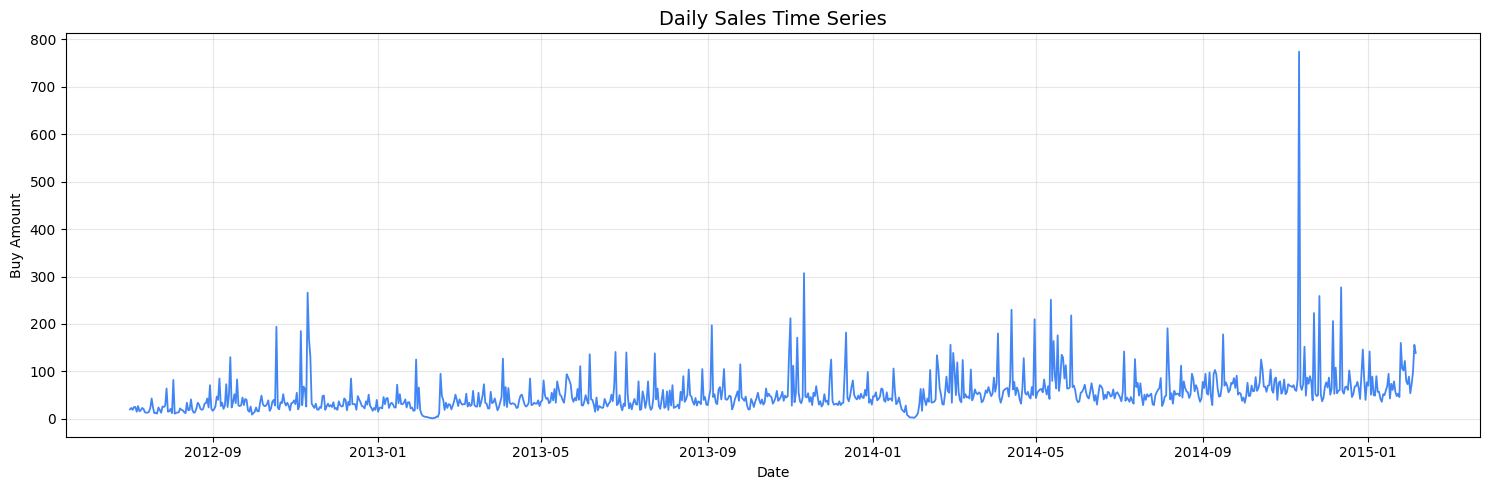

In [101]:
# 画日销量折线图
plt.figure(figsize=(15, 5))
sns.lineplot(x=y.index, y=y.values, color='#4285F4', linewidth=1.3)
plt.title('Daily Sales Time Series', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Buy Amount')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [106]:
# 2. 平稳性检验 ADF
adf_result = adfuller(y)
adf_stat = adf_result[0]
p_val = adf_result[1]
critical_vals = adf_result[4]

print(f'ADF 统计量 = {adf_stat:.4f}')
print(f'p-value    = {p_val:.4f}')
print('临界值:')
for k, v in critical_vals.items():
    print(f'  {k}: {v:.4f}')
if p_val < 0.05:
    print("数据平稳 → 可直接建 ARMA / AR")
else:
    print("数据不平稳 → 需要差分 → 建 ARIMA")

ADF 统计量 = -4.0270
p-value    = 0.0013
临界值:
  1%: -3.4374
  5%: -2.8646
  10%: -2.5684
数据平稳 → 可直接建 ARMA / AR


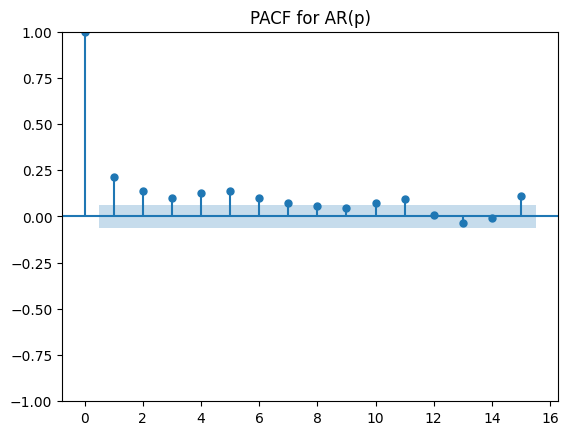

In [109]:
plot_pacf(y, lags=15, method="ywm")
plt.title("PACF for AR(p)")
plt.show()

使用Box-Jenkins方法观察此图，我们认为p=2后截断，适合建立AR(2)模型

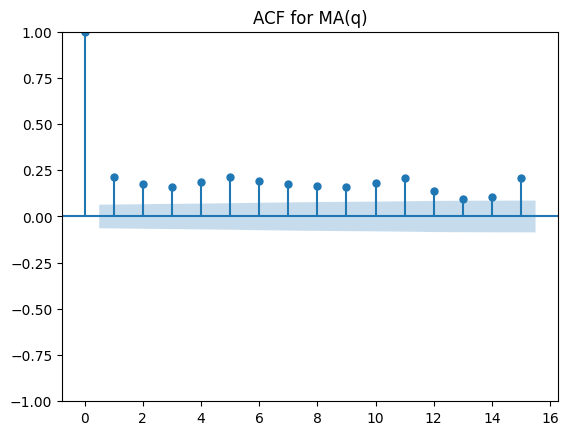

In [110]:
plot_acf(y, lags=15)
plt.title("ACF for MA(q)")
plt.show()

ACF从 q=1 开始呈现拖尾，优先建立MA(1)模型；接下来考虑Pandit-Wu方法，依次建立ARMA(2,1)，ARMA(4,3)模型

In [139]:
# 划分数据集
train = y[:-30]
test = y[-30:]
test_index = test.index  # 测试集日期坐标

# 定义要比较的 4 个模型
models = {
    "AR(2)":      (2, 0, 0),   # 纯AR
    "MA(1)":      (0, 0, 1),   # 纯MA
    "ARMA(2,1)":  (2, 0, 1),   # Pandit-Wu 低阶
    "ARMA(4,3)":  (4, 0, 3)    # Pandit-Wu 高阶
}

# 训练所有模型并计算误差
result = {}
# 存各模型预测值，用于画图
pred_dict = {}
# 保存每个训练模型对象，用于取残差
model_fit_dict = {}

for name, order in models.items():
    try:
        fit = ARIMA(train, order=order).fit()
        model_fit_dict[name] = fit
        pred = fit.predict(start=len(train), end=len(y)-1)
        pred_dict[name] = pred

        mae = mean_absolute_error(test, pred)
        mse = mean_squared_error(test, pred)
        rmse = np.sqrt(mse)
        aic = fit.aic
        bic = fit.bic
        result[name] = [mae, mse, rmse, aic, bic]
    except Exception as e:
        print(f"{name} 训练失败")

# 输出对比表
print("{:<10}{:>10}{:>10}{:>10}{:>10}{:>10}".format("模型", "MAE", "MSE", "RMSE", "AIC", "BIC"))
for name, metrics in result.items():
    print("{:<12}{:>10.2f}{:>10.2f}{:>10.2f}{:>10.2f}{:>10.2f}".format(
        name, metrics[0], metrics[1], metrics[2], metrics[3], metrics[4]))

# 自动选出最优模型（按 MAE 最小）
best_model = min(result.items(), key=lambda x: x[1][0])

print(f"最优模型 = {best_model[0]}")
print(f"最低 MAE = {best_model[1][0]:.2f}")

模型               MAE       MSE      RMSE       AIC       BIC
AR(2)            28.91   1735.10     41.65   9491.96   9511.26
MA(1)            28.88   1733.94     41.64   9514.23   9528.70
ARMA(2,1)        25.94   1151.26     33.93   9420.19   9444.30
ARMA(4,3)        26.18   1194.58     34.56   9427.29   9470.70
最优模型 = ARMA(2,1)
最低 MAE = 25.94


In [140]:
print("{:<10}{:<12}{:<12}{:<12}{:<12}".format("模型","LB6-p值","LB12-p值","DW统计量","结论"))

for m_name, fit_mod in model_fit_dict.items():
    res = fit_mod.resid
    # Ljung-Box检验 lag6、lag12
    lb_df = acorr_ljungbox(res, lags=[6,12], return_df=True)
    p6 = lb_df['lb_pvalue'].iloc[0]
    p12 = lb_df['lb_pvalue'].iloc[1]
    # DW检验：≈2无自相关，修正调用方式
    dw = durbin_watson(res.values)

    # 判断结论
    if p6>0.05 and p12>0.05:
        res_con = "残差独立(合格)"
    else:
        res_con = "残差自相关(不合格)"

    print("{:<10}{:<12.4f}{:<12.4f}{:<12.3f}{}".format(m_name,p6,p12,dw,res_con))

模型        LB6-p值      LB12-p值     DW统计量       结论          
AR(2)     0.0000      0.0000      2.026       残差自相关(不合格)
MA(1)     0.0000      0.0000      1.955       残差自相关(不合格)
ARMA(2,1) 0.7218      0.7730      1.998       残差独立(合格)
ARMA(4,3) 0.9295      0.9362      2.007       残差独立(合格)


到此为止，我们就已经成功建立了ARIMA(2,0,1)模型，但是模型的预测效果还是与实际差距较大，我们考虑机器学习方法改进。

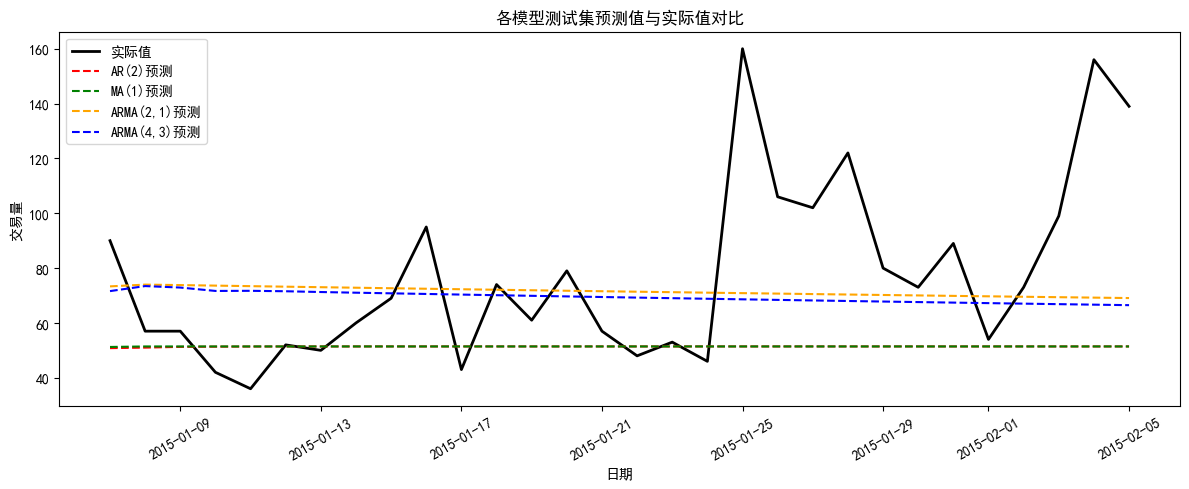

In [141]:
plt.rcParams['font.sans-serif'] = ['SimHei'] # 中文
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(12,5))

# 原始真实测试值（黑色实线）
plt.plot(test_index, test.values, 'k-', linewidth=2, label='实际值')

# 逐个绘制各模型预测
colors = ['r','g','orange','blue']
lab_list = list(pred_dict.keys())
for i,name in enumerate(lab_list):
    plt.plot(test_index, pred_dict[name], color=colors[i], linestyle='--', label=f'{name}预测')

plt.xlabel('日期')
plt.ylabel('交易量')
plt.legend()
plt.title('各模型测试集预测值与实际值对比')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 五、XGBoost 时序预测

===== XGBoost 预测误差 =====
MAE  = 25.01
MSE  = 1294.73
RMSE = 35.98


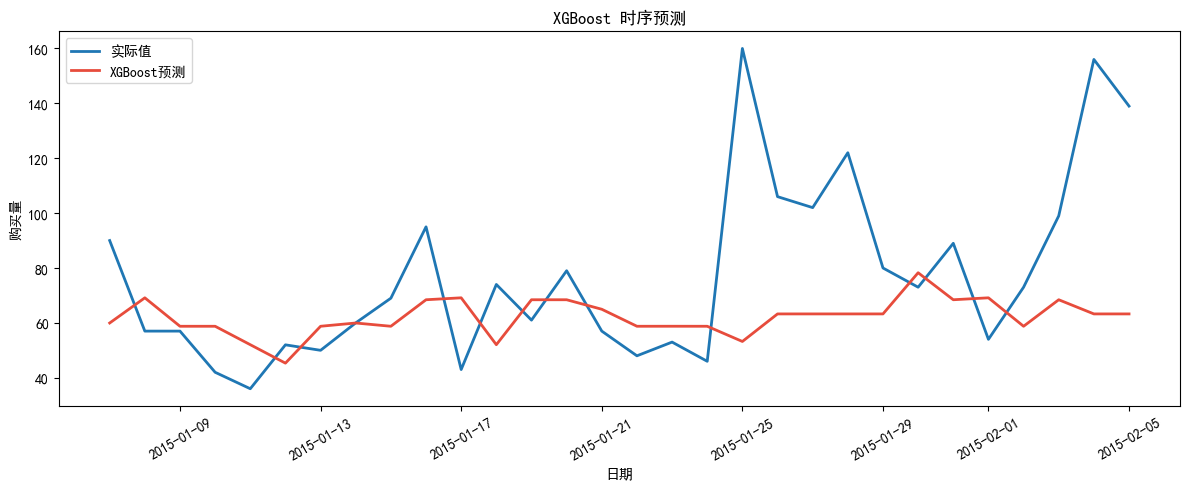


===== 残差独立性检验 (Ljung-Box) =====
      lb_stat  lb_pvalue
6    6.684262   0.351036
12  17.057402   0.147451


In [173]:
# 构造滞后特征（用前1天预测今天）
def create_lag_features(series, lag=1):
    df = pd.DataFrame(series)
    for i in range(1, lag+1):
        df[f'lag_{i}'] = df['buy_mount'].shift(i)
    df = df.dropna()
    X = df.drop('buy_mount', axis=1)
    y = df['buy_mount']
    return X, y

lag = 1
X, y_all = create_lag_features(y, lag=lag)

# 划分
split = len(train)
X_train = X.iloc[:split-lag]
y_train = y_all.iloc[:split-lag]
X_test = X.iloc[split-lag:split-lag+30]
y_test = y_all.iloc[split-lag:split-lag+30]

# 训练 XGBoost
model = xgb.XGBRegressor(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.05,
    objective='reg:squarederror',
    random_state=42
)
model.fit(X_train, y_train)

# 预测
y_pred = model.predict(X_test)

# 误差指标
mae = mean_absolute_error(test, y_pred)
mse = mean_squared_error(test, y_pred)
rmse = np.sqrt(mse)

print("===== XGBoost 预测误差 =====")
print(f"MAE  = {mae:.2f}")
print(f"MSE  = {mse:.2f}")
print(f"RMSE = {rmse:.2f}")

# 画图
plt.figure(figsize=(12,5))
plt.plot(test_index, test.values, label='实际值', linewidth=2)
plt.plot(test_index, y_pred, label='XGBoost预测', linewidth=2, color='#e74c3c')
plt.title('XGBoost 时序预测')
plt.xlabel('日期')
plt.ylabel('购买量')
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 残差独立性检验（Ljung-Box）
residuals = test.values - y_pred
lb_test = acorr_ljungbox(residuals, lags=[6,12], return_df=True)

print("\n===== 残差独立性检验 (Ljung-Box) =====")
print(lb_test)

p值均大于0.05，我们认为模型是合格的，效果略微好于ARIMA模型。